#### Audio classification data preprocessing

In [2]:
# lets read a sample audio file
import librosa
audio_file_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\24074-1-0-4.wav"
audio_data, sample_rate = librosa.load(audio_file_path)

In [3]:
audio_data

array([-0.02061145, -0.03201887, -0.03072608, ..., -0.01214315,
       -0.0188606 , -0.03248132], shape=(88200,), dtype=float32)

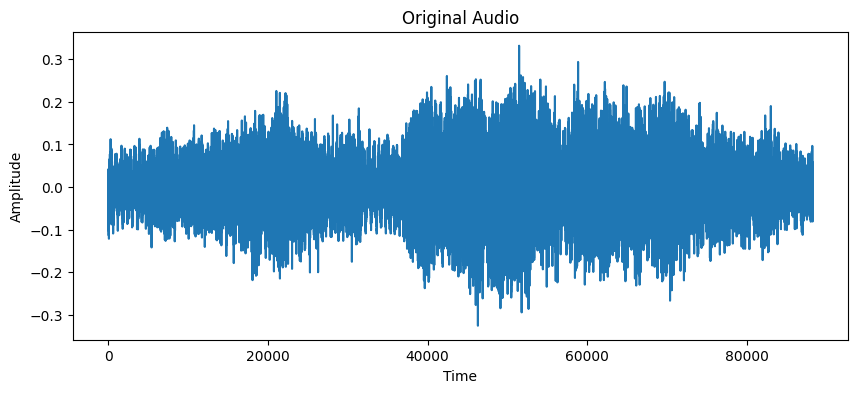

In [4]:
## Lets plot the librosa audio data
import matplotlib.pyplot as plt
#original audio with 1 channel
plt.figure(figsize=(10,4))
plt.plot(audio_data)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Original Audio")
plt.show()

### Observation
Here librosa converts the signal to a mono signal, meaning the channel will always be 1


In [5]:
## lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path)
wave_audio.shape

(176400, 2)

In [6]:
wave_audio

array([[-1077,  -767],
       [-1119,  -725],
       [-1256,  -700],
       ...,
       [-1222,  -397],
       [-1252,  -722],
       [-1259, -1052]], shape=(176400, 2), dtype=int16)

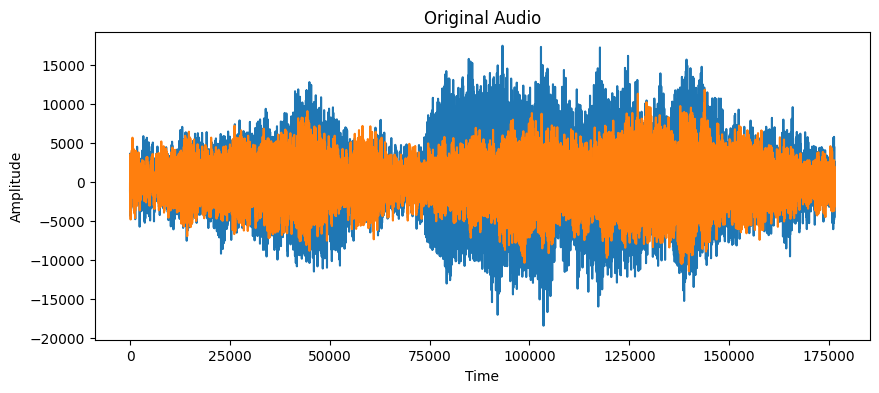

In [7]:
import matplotlib.pyplot as plt
#original audio with 2 channel
plt.figure(figsize=(10,4))
plt.plot(wave_audio)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Original Audio")
plt.show()

### extract features

Here we will be using Mel-Frequency Cepstral Coefficients(MFCC) fromt he audio samples. The MFCC summarizes the frequency distribution across the window size, so it is possible to analyse both the frequency and time characteristics of the sound. these audio representations will allow us to identfy features for classification.

In [8]:
mfcc = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)
mfcc.shape

(40, 173)

In [9]:
mfcc

array([[-260.14294  , -248.09836  , -252.69614  , ..., -257.83035  ,
        -252.96143  , -244.77193  ],
       [ 167.64651  ,  165.60715  ,  162.2457   , ...,  173.41843  ,
         163.77637  ,  148.22815  ],
       [ -41.750572 ,  -38.966362 ,  -34.434914 , ...,  -50.27221  ,
         -46.203705 ,  -39.12796  ],
       ...,
       [  -8.577814 ,   -8.295843 ,   -7.943085 , ...,  -10.744289 ,
         -17.186613 ,  -19.697432 ],
       [ -13.960558 ,  -12.552838 ,  -10.111483 , ...,   -8.430209 ,
         -11.161094 ,   -9.142506 ],
       [   9.559399 ,   10.2031975,    7.560831 , ...,   10.85211  ,
          12.680516 ,   13.859481 ]], shape=(40, 173), dtype=float32)

In [10]:
# extracting MFCC for every audio file
import os
import pandas as pd
import librosa

In [11]:
audio_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\audio"
meta_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\metadata\UrbanSound8K.csv"
metadata = pd.read_csv(meta_path)
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [12]:
def feature_extractor(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccsscaled = np.mean(mfccs.T,axis=0)
    return mfccsscaled

In [13]:
import numpy as np
from tqdm import tqdm

In [14]:
!pip install resampy

In [15]:
# now we will iterate through all the  audio filesand extract the features  
extracted_features = []
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_path), 'fold'+str(row["fold"])+'/', str(row["slice_file_name"]))
    final_class_labels = row["class"]
    data = feature_extractor(file_name)
    extracted_features.append([data, final_class_labels])

3555it [05:12, 12.77it/s]d:\Coding\DeepLearning\.dlenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8326it [12:50, 21.02it/s]d:\Coding\DeepLearning\.dlenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
d:\Coding\DeepLearning\.dlenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [13:27, 10.82it/s]


In [16]:
extracted_features_df = pd.DataFrame(extracted_features, columns=["feature", "class"])
extracted_features_df.head()

,feature,class
0,"[-217.35526, 70.22339, -130.38527, -53.282898,...",dog_bark
1,"[-424.09818, 109.34077, -52.919525, 60.86475, ...",children_playing
2,"[-458.79114, 121.38419, -46.520657, 52.00812, ...",children_playing
3,"[-413.89984, 101.66371, -35.42945, 53.036358, ...",children_playing
4,"[-446.60352, 113.68541, -52.402214, 60.302044,...",children_playing


In [17]:
X = np.array(extracted_features_df["feature"].tolist())
y = np.array(extracted_features_df["class"].tolist())

In [18]:
X.shape

(8732, 40)

In [19]:
y = np.array(pd.get_dummies(y))

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6985, 40), (1747, 40), (6985, 10), (1747, 10))